In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sqoct_core import (
    A, B, C, D,
    onsite_clean,
    onsite_impurity,
    hopping_bdg,
    build_ysr_system,
    low_energy_states,
    ysr_energy,
    scan_ysr_vs_J
)

from sympy import Matrix, nsimplify
from IPython.display import display

In [2]:
from IPython.display import display, HTML
from IPython.core.magic import register_cell_magic
import uuid

display(HTML("""
<style>
.tutorial-note {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #4c8bf5;
    background: rgba(76, 139, 245, 0.08);
    border-radius: 4px;
}

.tutorial-important {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #e67e22;
    background: rgba(230, 126, 34, 0.08);
    border-radius: 4px;
}

.tutorial-warning {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #d9534f;
    background: rgba(217, 83, 79, 0.08);
    border-radius: 4px;
}

.tutorial-result {
    padding: 12px 16px;
    margin: 12px 0;
    border-left: 5px solid #2ca02c;
    background: rgba(44, 160, 44, 0.08);
    border-radius: 4px;
}
</style>
"""))



@register_cell_magic
def important(line, cell):
    marker = f"important-{uuid.uuid4().hex}"

    display(HTML(f"""
    <div id="{marker}"></div>

    <style>
    .jp-CodeCell:has(#{marker}) {{
        background: rgba(230, 126, 34, 0.08);
        border-left: 5px solid #e67e22;
        border-radius: 5px;
        padding-left: 6px;
    }}
    </style>
    """))

    get_ipython().run_cell(cell)

<div class="tutorial-note">

We can construct the hamiltonian, build the YSR system and even get YSR values as well. Next we want to work with the BdG eigenvectors.
We convert the BdG eigenvectors obtained into a probability weight on each physical lattice site and from these weights we calculate the
inverse participation ratio, the weight on the magnetic impurity site, and the total weight carried by each $A,B,C,D$ sublattice.

</div>

In [3]:
Nx = 2
Ny = 2

t1 = 1.0
t2 = 0.5

mu = 0.3
Delta = 0.2
J = 0.6


fsyst, impurity_site, impurity_index = build_ysr_system(
    Nx, Ny,
    t1=t1, t2=t2,
    impurity_sublattice="A"
)

print("Number of physical sites =", len(fsyst.sites))
print("BdG dimension =", 4 * len(fsyst.sites))
print("Impurity =", impurity_site)
print("Impurity index =", impurity_index)

Number of physical sites = 16
BdG dimension = 64
Impurity = <Site [1 1] of sqo0>
Impurity index = 11


## Low-energy eigenvalues and eigenvectors

<div class="tutorial-note">
For this $2\times2$ lattice, wavefunction ($\Psi$) has 64 components (16 sites $\times$ 4 BdG components)

The eigenvector looks schematically like

$$
\psi=
(\psi_{1\uparrow},
\psi_{1\downarrow},
\psi_{1\uparrow}^h,
\psi_{1\downarrow}^h,
\psi_{2\uparrow},\ldots).
$$
</div>

In [4]:
vals, vecs = low_energy_states(
    fsyst,
    J=J, mu=mu, Delta=Delta,
    k=6, return_vectors=True
)

print("Low-energy eigenvalues:")
print(vals)

Low-energy eigenvalues:
[-0.33481521 -0.31751073 -0.19188759  0.19188759  0.31751073  0.33481521]


In [5]:
index = np.argmin(np.abs(vals))

E_ysr = vals[index]
psi = vecs[:, index]

print("YSR energy =", E_ysr)
print("Eigenvector length =", len(psi))

YSR energy = -0.1918875924380812
Eigenvector length = 64


<div class="tutorial-note">

For site $i$,

$$
w_i
=
\sum_{\alpha=1}^{4}
|\psi_{i\alpha}|^2.
$$

</div>

In [6]:
nsites = len(fsyst.sites)

psi_site = psi.reshape(nsites, 4)

print("Original shape =", psi.shape)
print("Reshaped =", psi_site.shape)

# Each row now corresponds to one physical site.
print("Site 0 =", fsyst.sites[0])
print("BdG amplitudes on site 0:")

Matrix(psi_site[0])

Original shape = (64,)
Reshaped = (16, 4)
Site 0 = <Site [0 0] of sqo1>
BdG amplitudes on site 0:


Matrix([
[     0.015476934344143 - 0.0636126173194351*I],
[1.17732707020433e-17 + 4.58518526227094e-17*I],
[1.25216436909754e-16 - 3.88602305934146e-17*I],
[   -0.0113334223443231 + 0.0465821358725213*I]])

<div class="tutorial-note">
Above four entries correspond to

$$
(c_\uparrow,\,
c_\downarrow,\,
c_\uparrow^\dagger,\,
c_\downarrow^\dagger)
$$

for that one physical site.
</div>

In [7]:
# Calculate site weights
weights = np.sum(np.abs(psi_site)**2, axis=1).real

print(weights)
print("Sum of site weights =", np.sum(weights))

[0.00658444 0.04720787 0.00175359 0.02092355 0.00242243 0.00033505
 0.13099626 0.11953772 0.00083896 0.00899568 0.14944687 0.2376466
 0.00636034 0.05334076 0.04720787 0.16640202]
Sum of site weights = 0.9999999999999991


<div class="tutorial-note">
We arrange the above into a function to calculate the site weights
</div>

In [8]:
%%important

def state_site_weights(fsyst, psi):

    nsites = len(fsyst.sites)
    psi_site = np.asarray(psi).reshape(nsites, 4)

    weights = np.sum(
        np.abs(psi_site)**2,
        axis=1
    ).real

    weights = weights / np.sum(weights)

    return weights

In [9]:
weights = state_site_weights(fsyst, psi)

print(weights)
print("Sum =", weights.sum())

[0.00658444 0.04720787 0.00175359 0.02092355 0.00242243 0.00033505
 0.13099626 0.11953772 0.00083896 0.00899568 0.14944687 0.2376466
 0.00636034 0.05334076 0.04720787 0.16640202]
Sum = 1.0


<div class="tutorial-note">

`state_ipr()`

The inverse participation ratio tells us how localized the state is:

$$
\mathrm{IPR}
=
\sum_i w_i^2,
$$

where the site weights are normalized so that $ \sum_i w_i=1$. For a state spread uniformly over $N$ sites, $ w_i=\frac1N $ and therefore

$$
\mathrm{IPR}=\frac1N.
$$

For a state completely localized on one site, $\mathrm{IPR}=1$.

</div>

In [10]:
%%important

def state_ipr(weights):

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    return np.sum(weights**2)

In [11]:
print(state_ipr(weights))

0.14586388098861935


## Weight of the YSR state on the impurity site

In [12]:
%%important

def impurity_weight(weights, impurity_index):

    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    return weights[impurity_index]

In [13]:
W_imp = impurity_weight(weights,impurity_index)

print("W_imp =", W_imp)

W_imp = 0.23764660183546843


<div class="tutorial-note">

**How much of the whole YSR wavefunction lives on the A, B, C, and D sublattices?**

$$
W_A
=
\sum_{i\in A}w_i,
$$

and similarly for $B,C,D$. Since the total state is normalized,

$$
W_A+W_B+W_C+W_D=1.
$$

</div>

In [14]:
# First find the respective sublattices

A_indices = [
    i
    for i, site in enumerate(fsyst.sites)
    if site.family == A
]

print("A-site indices =", A_indices)

B_indices = [
    i
    for i, site in enumerate(fsyst.sites)
    if site.family == B
]

print("B-site indices =", B_indices)

C_indices = [
    i
    for i, site in enumerate(fsyst.sites)
    if site.family == C
]

print("C-site indices =", C_indices)

D_indices = [
    i
    for i, site in enumerate(fsyst.sites)
    if site.family == D
]

print("D-site indices =", D_indices)

A-site indices = [8, 9, 10, 11]
B-site indices = [0, 1, 2, 3]
C-site indices = [4, 5, 6, 7]
D-site indices = [12, 13, 14, 15]


In [15]:
W_A = np.sum(weights[A_indices])
W_B = np.sum(weights[B_indices])
W_C = np.sum(weights[C_indices])
W_D = np.sum(weights[D_indices])

print("A =", W_A)
print("B =", W_B)
print("C =", W_C)
print("D =", W_D)

print("Total =", W_A + W_B + W_C + W_D)

A = 0.39692810738674733
B = 0.07646944413841085
C = 0.25329146154265486
D = 0.2733109869321869
Total = 0.9999999999999999


In [16]:
%%important

def sublattice_weights(
    fsyst,
    weights
):

    weights = np.asarray(
        weights,
        dtype=float
    )

    weights = weights / weights.sum()

    out = {}

    for label, family in {
        "A": A,
        "B": B,
        "C": C,
        "D": D
    }.items():

        indices = [
            i
            for i, site in enumerate(fsyst.sites)
            if site.family == family
        ]

        out[label] = np.sum(
            weights[indices]
        )

    return out

In [17]:
sub_weights = sublattice_weights(fsyst, weights)

print(sub_weights)

{'A': np.float64(0.39692810738674733), 'B': np.float64(0.07646944413841085), 'C': np.float64(0.25329146154265486), 'D': np.float64(0.2733109869321869)}


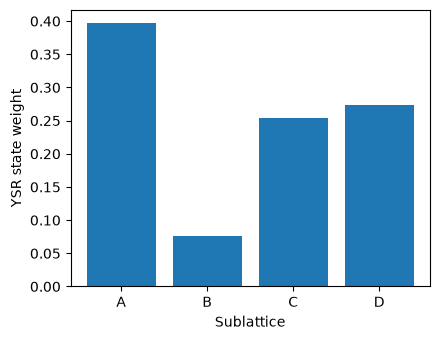

In [18]:
labels = ["A", "B", "C", "D"]

values = [
    sub_weights["A"],
    sub_weights["B"],
    sub_weights["C"],
    sub_weights["D"]
]


fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.bar(labels, values)

ax.set_xlabel("Sublattice")
ax.set_ylabel("YSR state weight")

plt.tight_layout()
plt.show()

In [19]:
for J_test in [0.2, 0.6, 1.0]:

    vals, vecs = low_energy_states(
        fsyst,
        J=J_test, mu=mu, Delta=Delta,
        k=6, return_vectors=True
    )

    index = np.argmin(np.abs(vals))

    E = vals[index]
    psi = vecs[:, index]

    weights = state_site_weights(fsyst, psi)

    ipr = state_ipr(weights)

    W_imp = impurity_weight(weights, impurity_index)

    print(
        f"J={J_test:.2f}   "
        f"E={E:+.5f}   "
        f"IPR={ipr:.4f}   "
        f"W_imp={W_imp:.4f}"
    )

J=0.20   E=-0.27348   IPR=0.0873   W_imp=0.1499
J=0.60   E=+0.19189   IPR=0.1459   W_imp=0.2376
J=1.00   E=+0.09909   IPR=0.1706   W_imp=0.2132
